# Testes para normalidade univariada

## Teste de Kolmogorov-Smirnov

O teste de Kolmogorov-Smirnov (K-S) é um teste de aderência, isto é, compara a distribuição de frequências acumuladas de um conjunto de valores amostrais (valores observados) com uma distribuição teórica. O objetivo é testar se os valores amostrais são oriundos de uma população com suposta distribuição teórica ou esperada,
no nosso caso a distribuição normal. A estatística do teste é o ponto de maior diferença (em valor absoluto) entre as duas distribuições.

Para utilização do teste de K-S, a média e o desvio-padrão da população devem ser conhecidos. Para pequenas amostras, o teste perde potência, de modo que deve ser utilizado em amostras relativamente grandes ($n \ge 30$).

O teste de K-S assume as seguintes hipóteses:

- $H_0$: a amostra provém de uma população com determinada distribuição
- $H_1$: a amostra não provém de uma população com determinada distribuição

Exemplo: A base de dados abaixo apresenta os dados de produção mensal de máquinas agrícolas de uma empresa nos últimos 36 meses. Verifique se os dados são provenientes de uma população com distribuição normal, considerando $\alpha = 5 \%$.

In [1]:
import pandas as pd

DADOS_MAQUINAS_AGRICOLAS = "./dados/farming_equipment.csv"

df_maquinas_agricolas = pd.read_csv(DADOS_MAQUINAS_AGRICOLAS)

df_maquinas_agricolas.head()

,production
0,52
1,50
2,44
3,50
4,42


In [3]:
df_maquinas_agricolas.tail()

,production
31,55
32,50
33,34
34,44
35,42


In [4]:
df_maquinas_agricolas.describe()

,production
count,36.000000
mean,42.638889
std,7.099911
min,30.000000
25%,37.500000
50%,42.000000
75%,48.500000
max,55.000000


In [6]:
df_maquinas_agricolas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   production  36 non-null     int64
dtypes: int64(1)
memory usage: 420.0 bytes


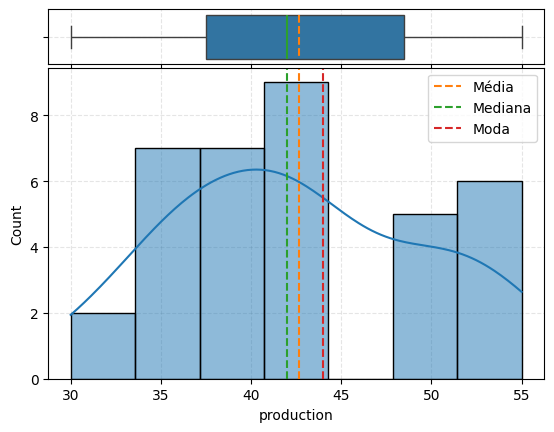

In [5]:
from auxiliares import composicao_histograma

composicao_histograma(df_maquinas_agricolas,"production")

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_1samp.html

In [10]:
from scipy.stats import ks_1samp, norm,kstest,zscore

ks_1samp(df_maquinas_agricolas["production"],
         norm.cdf,
         args=(df_maquinas_agricolas["production"].mean(),df_maquinas_agricolas["production"].std())
         )


KstestResult(statistic=np.float64(0.1184298337535814), pvalue=np.float64(0.6502794267036324), statistic_location=np.float64(44.0), statistic_sign=np.int8(1))

In [8]:
kstest(df_maquinas_agricolas["production"],
         norm.cdf,
         args=(df_maquinas_agricolas["production"].mean(),df_maquinas_agricolas["production"].std())
         )

KstestResult(statistic=np.float64(0.1184298337535814), pvalue=np.float64(0.6502794267036324), statistic_location=np.float64(44.0), statistic_sign=np.int8(1))

In [9]:
kstest(df_maquinas_agricolas["production"],
         norm.cdf,
         #args=(df_maquinas_agricolas["production"].mean(),df_maquinas_agricolas["production"].std())
         )

KstestResult(statistic=np.float64(1.0), pvalue=np.float64(0.0), statistic_location=np.float64(30.0), statistic_sign=np.int8(-1))

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.html

In [12]:
df_maquinas_agricolas["zscore"]= zscore(df_maquinas_agricolas["production"],ddof=1)

df_maquinas_agricolas.head()

,production,zscore
0,52,1.318483
1,50,1.036789
2,44,0.191708
3,50,1.036789
4,42,-0.089985


In [13]:
kstest(df_maquinas_agricolas["zscore"],
         norm.cdf,
         #args=(df_maquinas_agricolas["production"].mean(),df_maquinas_agricolas["production"].std())
         )

KstestResult(statistic=np.float64(0.1184298337535814), pvalue=np.float64(0.6502794267036324), statistic_location=np.float64(0.19170820490280965), statistic_sign=np.int8(1))

Como $pvalue > 0.05$, não rejeitamos a hipótese nula, o que permite concluir com 95% de confiança que a distribuição é normal